#**Project: Smart Fraud Detection Pipeline**
##Gold Layer: Fraud Detection & Business Analytics

**Author:** Snehal A. Bhosale  
**College:** Sanjivani College of Engineering, Kopargaon  
**Email:** snehalbhosale1807@gmail.com  
**Student ID:** CT_CSI_DE_1177  
**Technology:** PySpark, Spark SQL, Parquet  

## **Objective**
To identify potentially fraudulent transactions by matching cleaned transactions
(from the Silver layer) against the fraud watchlist, classify each transaction as
`fraud` or `normal`, and generate business-level fraud analytics — using both
PySpark DataFrame API and Spark SQL.

### **Step 1: Import Libraries**

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col,
    when,
    count,
    sum as spark_sum,
    avg,
    round as spark_round,
    desc,
    row_number,
    dense_rank,
    month,
    lit

)
from pyspark.sql.window import Window


### **Step 2: Start Spark**

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col,
    when,
    count,
    sum,
    round,
    avg,
    desc,
    lit
)

spark = (
    SparkSession.builder
    .appName("SmartFraudDetection_Gold")
    .getOrCreate()
)

print("Spark Version:", spark.version)

Spark Version: 4.0.3


### **Step 3: Upload Silver Data**


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving silver_accounts.csv to silver_accounts.csv
Saving silver_enriched_transactions.csv to silver_enriched_transactions.csv
Saving silver_fraud_watchlist.csv to silver_fraud_watchlist.csv
Saving silver_transactions.csv to silver_transactions.csv


### **Step 4: Read the Four Silver CSV Files**

In [ ]:
accounts = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv("silver_accounts.csv")
)

enriched_transactions = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv("silver_enriched_transactions.csv")
)

fraud_watchlist = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv("silver_fraud_watchlist.csv")
)

transactions = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv("silver_transactions.csv")
)

### **Step 5: Check Record Counts**

In [ ]:
print("Silver Accounts:", accounts.count())
print("Silver Transactions:", transactions.count())
print("Silver Enriched Transactions:", enriched_transactions.count())
print("Silver Fraud Watchlist:", fraud_watchlist.count())

Silver Accounts: 501
Silver Transactions: 20004
Silver Enriched Transactions: 20004
Silver Fraud Watchlist: 43


### **Step 6: Inspect Schemas**

In [ ]:
print("========== ACCOUNTS ==========")
accounts.printSchema()

print("========== TRANSACTIONS ==========")
transactions.printSchema()

print("========== ENRICHED TRANSACTIONS ==========")
enriched_transactions.printSchema()

print("========== FRAUD WATCHLIST ==========")
fraud_watchlist.printSchema()

========== ACCOUNTS ==========
root
 |-- account_id: string (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- account_type: string (nullable = true)
 |-- credit_limit: double (nullable = true)
 |-- branch: string (nullable = true)
 |-- ingestion_timestamp: timestamp (nullable = true)
 |-- source_system: string (nullable = true)

========== TRANSACTIONS ==========
root
 |-- txn_id: string (nullable = true)
 |-- account_id: string (nullable = true)
 |-- txn_date: date (nullable = true)
 |-- amount: double (nullable = true)
 |-- merchant: string (nullable = true)

========== ENRICHED TRANSACTIONS ==========
root
 |-- txn_id: string (nullable = true)
 |-- account_id: string (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- account_type: string (nullable = true)
 |-- credit_limit: double (nullable = true)
 |-- branch: string (nullable = true)
 |-- txn_date: date (nullable = true)
 |-- amount: double (nullable = true)
 |-- merchant: string (nullable = true

### **Step 6: Check Sample Data**

In [ ]:
accounts.show(5, truncate=False)

transactions.show(5, truncate=False)

fraud_watchlist.show(5, truncate=False)

+----------+-------------+------------+------------+------+-----------------------+-------------+
|account_id|customer_name|account_type|credit_limit|branch|ingestion_timestamp    |source_system|
+----------+-------------+------------+------------+------+-----------------------+-------------+
|ACC0001   |Customer_1   |Savings     |100000.0    |Mumbai|2026-08-08 12:43:11.286|accounts.csv |
|ACC0002   |Customer_2   |Salary      |200000.0    |Delhi |2026-08-08 12:43:11.286|accounts.csv |
|ACC0003   |Customer_3   |Savings     |100000.0    |Mumbai|2026-08-08 12:43:11.286|accounts.csv |
|ACC0004   |Customer_4   |Salary      |50000.0     |Pune  |2026-08-08 12:43:11.286|accounts.csv |
|ACC0005   |Customer_5   |Current     |50000.0     |Mumbai|2026-08-08 12:43:11.286|accounts.csv |
+----------+-------------+------------+------------+------+-----------------------+-------------+
only showing top 5 rows
+---------+----------+----------+--------+---------+
|txn_id   |account_id|txn_date  |amount  

### **Step 7: Standardize Important Columns**

In [ ]:
transactions = (
    transactions
    .withColumn("txn_id", col("txn_id").cast("string"))
    .withColumn("account_id", col("account_id").cast("string"))
    .withColumn("amount", col("amount").cast("double"))
)

fraud_watchlist = (
    fraud_watchlist
    .withColumn("account_id", col("account_id").cast("string"))
    .withColumn("fraud_type", col("fraud_type").cast("string"))
)

accounts = (
    accounts
    .withColumn("account_id", col("account_id").cast("string"))
    .withColumn("credit_limit", col("credit_limit").cast("double"))
)

### **Step 8: Main Fraud Detection Join.**

In [ ]:
from pyspark.sql.functions import col, when

gold_transactions = (
    transactions.alias("t")
    .join(
        fraud_watchlist.select(
            col("account_id").alias("fraud_account_id"),
            col("fraud_type"),
            col("flagged_date")
        ).alias("f"),
        col("t.account_id") == col("f.fraud_account_id"),
        "left"
    )
)

### **Step 9: Create Fraud Classification**

In [ ]:
gold_transactions = (
    gold_transactions
    .withColumn(
        "fraud_flag",
        when(
            col("fraud_type").isNotNull(),
            "fraud"
        ).otherwise("normal")
    )
)

### **Step 10: Risk Level**

In [ ]:
gold_transactions = gold_transactions.select(
    col("t.txn_id").alias("txn_id"),
    col("t.account_id").alias("account_id"),
    col("t.amount").alias("amount"),
    col("t.merchant").alias("merchant"),
    col("t.txn_date").alias("txn_date"),
    col("fraud_type"),
    col("flagged_date"),
    col("fraud_flag")
)

In [ ]:
gold_transactions = gold_transactions.withColumn(
    "risk_level",
    when(
        col("fraud_flag") == "fraud",
        when(col("amount") >= 100000, "Critical")
        .when(col("amount") >= 50000, "High")
        .otherwise("Medium")
    ).otherwise(
        when(col("amount") >= 100000, "High")
        .otherwise("Low")
    )
)

gold_transactions.show(10, truncate=False)

+---------+----------+--------+--------------+----------+----------+------------+----------+----------+
|txn_id   |account_id|amount  |merchant      |txn_date  |fraud_type|flagged_date|fraud_flag|risk_level|
+---------+----------+--------+--------------+----------+----------+------------+----------+----------+
|TXN000001|ACC0065   |45458.55|Flipkart      |2025-06-10|NULL      |NULL        |normal    |Low       |
|TXN000002|ACC0258   |25336.95|Swiggy        |2025-06-14|NULL      |NULL        |normal    |Low       |
|TXN000003|ACC0088   |93690.65|BigBasket     |2025-06-18|NULL      |NULL        |normal    |Low       |
|TXN000004|ACC0432   |6227.09 |Amazon        |2025-05-25|NULL      |NULL        |normal    |Low       |
|TXN000005|ACC0042   |142284.6|Uber          |2025-01-12|NULL      |NULL        |normal    |High      |
|TXN000006|ACC0334   |115055.5|Unknown_POS   |2025-02-23|NULL      |NULL        |normal    |High      |
|TXN000007|ACC0317   |4591.37 |Uber          |2025-06-13|NULL   

### **Step 11: Fraud Summary**

In [ ]:
fraud_summary = gold_transactions.groupBy("fraud_flag").agg(
    count("*").alias("transaction_count"),
    round(sum("amount"), 2).alias("total_amount")
)

fraud_summary.show()

+----------+-----------------+---------------+
|fraud_flag|transaction_count|   total_amount|
+----------+-----------------+---------------+
|    normal|            18339|1.38887952489E9|
|     fraud|             1665| 1.2501966324E8|
+----------+-----------------+---------------+



### **Step 12: Account-Level Fraud Analysis**

In [ ]:
fraud_per_account = (
    gold_transactions
    .filter(col("fraud_flag") == "fraud")
    .groupBy("account_id", "fraud_type")
    .agg(
        count("*").alias("fraud_transactions"),
        round(sum("amount"), 2).alias("fraud_amount")
    )
    .orderBy(desc("fraud_amount"))
)

fraud_per_account.show(10, truncate=False)

+----------+----------------+------------------+------------+
|account_id|fraud_type      |fraud_transactions|fraud_amount|
+----------+----------------+------------------+------------+
|ACC0072   |Account Takeover|47                |4410467.66  |
|ACC0352   |Phishing        |57                |4348221.0   |
|ACC0233   |Account Takeover|50                |3670996.74  |
|ACC0423   |Account Takeover|44                |3570870.0   |
|ACC0071   |Phishing        |45                |3549528.55  |
|ACC0178   |Card Skimming   |39                |3484161.03  |
|ACC0192   |Phishing        |44                |3468192.78  |
|ACC0154   |Identity Theft  |36                |3420859.93  |
|ACC0013   |Card Skimming   |39                |3393566.87  |
|ACC0066   |Account Takeover|40                |3299823.0   |
+----------+----------------+------------------+------------+
only showing top 10 rows


### **Step 13: Spark SQL Analysis**

In [ ]:
gold_transactions.createOrReplaceTempView("gold_transactions")

spark.sql("""
SELECT
    fraud_flag,
    COUNT(*) AS transaction_count,
    ROUND(SUM(amount), 2) AS total_amount
FROM gold_transactions
GROUP BY fraud_flag
ORDER BY transaction_count DESC
""").show()

+----------+-----------------+---------------+
|fraud_flag|transaction_count|   total_amount|
+----------+-----------------+---------------+
|    normal|            18339|1.38887952489E9|
|     fraud|             1665| 1.2501966324E8|
+----------+-----------------+---------------+



### Step 14: Fraud Rate & Total Fraud Amount

### **Step 15: Save Final Gold Outputs**

In [ ]:
total_txns = gold_transactions.count()

fraud_txns = gold_transactions.filter(
    col("fraud_flag") == "fraud"
).count()

fraud_amount = gold_transactions.filter(
    col("fraud_flag") == "fraud"
).agg(
    sum("amount")
).collect()[0][0]

fraud_rate = (fraud_txns / total_txns) * 100

print("Total Transactions :", total_txns)
print("Fraud Transactions :", fraud_txns)
print("Fraud Rate         :", f"{fraud_rate:.2f}%")
print("Fraud Amount       :", f"{fraud_amount or 0:.2f}")

Total Transactions : 20004
Fraud Transactions : 1665
Fraud Rate         : 8.32%
Fraud Amount       : 125019663.24


In [ ]:
import os
os.makedirs("gold", exist_ok=True)

gold_transactions.write.mode("overwrite").parquet(
    "gold/fraud_transactions"
)

fraud_summary.write.mode("overwrite").parquet(
    "gold/fraud_summary"
)

fraud_per_account.write.mode("overwrite").parquet(
    "gold/fraud_per_account"
)

print("✅ Gold layer completed and saved successfully.")

✅ Gold layer completed and saved successfully.


### **Step 16: Final Validation**

In [ ]:
print("========== FINAL GOLD VALIDATION ==========")

print("Gold Records:", gold_transactions.count())

print(
    "Null Fraud Flags:",
    gold_transactions.filter(
        col("fraud_flag").isNull()
    ).count()
)

print(
    "Fraud Transactions:",
    gold_transactions.filter(
        col("fraud_flag") == "fraud"
    ).count()
)

========== FINAL GOLD VALIDATION ==========
Gold Records: 20004
Null Fraud Flags: 0
Fraud Transactions: 1665


### **Step 17: Download the Gold Layer Output**

In [ ]:
import os
import shutil
from google.colab import files

# Create download folder
os.makedirs("gold_csv", exist_ok=True)

# Convert Gold DataFrames to CSV
gold_transactions.coalesce(1).write \
    .mode("overwrite") \
    .option("header", True) \
    .csv("gold_csv/fraud_transactions")

fraud_summary.coalesce(1).write \
    .mode("overwrite") \
    .option("header", True) \
    .csv("gold_csv/fraud_summary")

fraud_per_account.coalesce(1).write \
    .mode("overwrite") \
    .option("header", True) \
    .csv("gold_csv/fraud_per_account")

print("✅ Gold CSV files created.")

✅ Gold CSV files created.


In [ ]:
import shutil
import os
from google.colab import files

def get_csv_file(folder):
    for file in os.listdir(folder):
        if file.endswith(".csv"):
            return os.path.join(folder, file)

shutil.copy(
    get_csv_file("gold_csv/fraud_transactions"),
    "gold_fraud_transactions.csv"
)

shutil.copy(
    get_csv_file("gold_csv/fraud_summary"),
    "gold_fraud_summary.csv"
)

shutil.copy(
    get_csv_file("gold_csv/fraud_per_account"),
    "gold_fraud_per_account.csv"
)

files.download("gold_fraud_transactions.csv")
files.download("gold_fraud_summary.csv")
files.download("gold_fraud_per_account.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'gold_csv/fraud_transactions'

### **Step 18: Visualization**

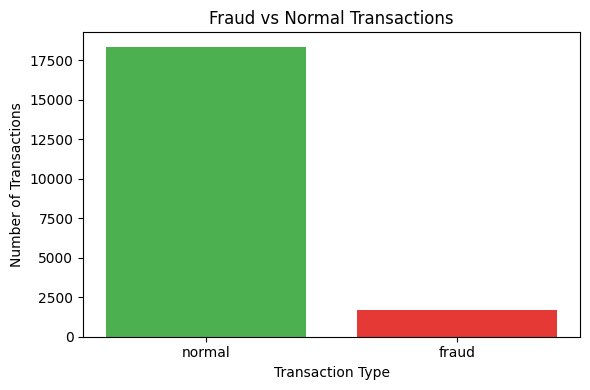

In [ ]:
import matplotlib.pyplot as plt

summary_pd = fraud_summary.toPandas()

plt.figure(figsize=(6, 4))
plt.bar(summary_pd["fraud_flag"], summary_pd["transaction_count"], color=["#4CAF50", "#E53935"])
plt.title("Fraud vs Normal Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

**Fraud by Type**

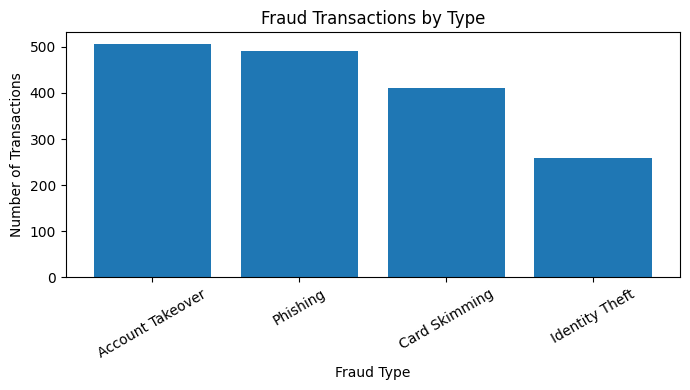

In [ ]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import count, sum, round, desc

fraud_by_type = (
    gold_transactions
    .filter(col("fraud_flag") == "fraud")
    .groupBy("fraud_type")
    .agg(
        count("*").alias("fraud_transactions"),
        round(sum("amount"), 2).alias("fraud_amount")
    )
    .orderBy(desc("fraud_transactions"))
)

fraud_type_pd = fraud_by_type.toPandas()

plt.figure(figsize=(7, 4))
plt.bar(
    fraud_type_pd["fraud_type"],
    fraud_type_pd["fraud_transactions"]
)

plt.title("Fraud Transactions by Type")
plt.xlabel("Fraud Type")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Fraud Vs Normal Transaction**

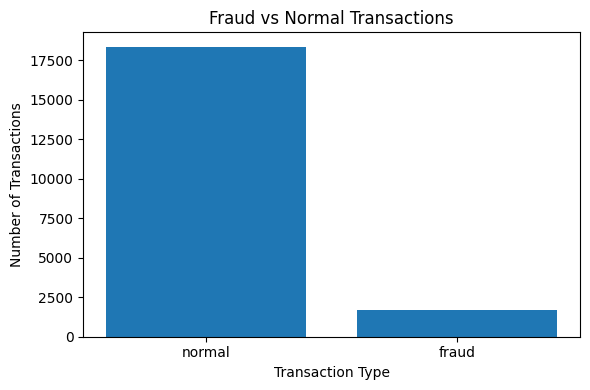

In [ ]:
summary_pd = fraud_summary.toPandas()

plt.figure(figsize=(6, 4))
plt.bar(
    summary_pd["fraud_flag"],
    summary_pd["transaction_count"]
)

plt.title("Fraud vs Normal Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

**Fraud Rate by Branch**

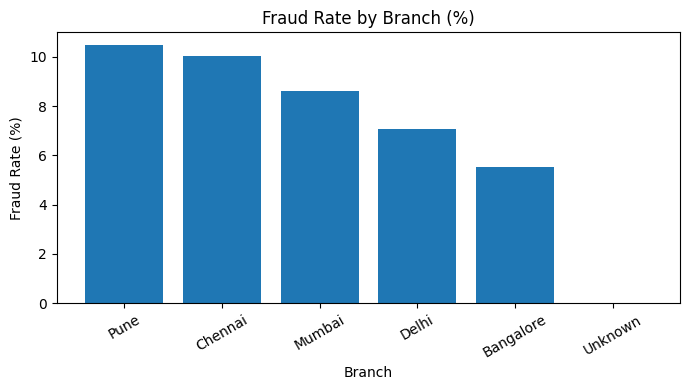

In [ ]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import count, sum, round, when, col

# Create branch-level data
branch_fraud = (
    gold_with_branch
    .withColumn("branch", when(col("branch").isNull(), "Unknown").otherwise(col("branch")))
    .groupBy("branch")
    .agg(
        count("*").alias("total_transactions"),
        sum(
            when(col("fraud_flag") == "fraud", 1).otherwise(0)
        ).alias("fraud_transactions")
    )
    .withColumn(
        "fraud_rate",
        round(
            col("fraud_transactions") /
            col("total_transactions") * 100,
            2
        )
    )
    .orderBy(col("fraud_rate").desc())
)

# Convert to Pandas
branch_pd = branch_fraud.toPandas()

# Plot
plt.figure(figsize=(7, 4))
plt.bar(
    branch_pd["branch"].astype(str),
    branch_pd["fraud_rate"]
)

plt.title("Fraud Rate by Branch (%)")
plt.xlabel("Branch")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## **Conclusion**

The Gold layer successfully transformed the cleaned Silver data into
actionable fraud detection results. Watchlist-based matching was used to
classify transactions as fraud or normal, while additional risk indicators
and aggregations provided account, branch, merchant, and fraud-type insights.

The final Gold datasets (Parquet in `gold/`, flat CSVs in `output/`) are
ready for fraud monitoring dashboards or as training data for a future
machine-learning fraud-scoring model.